# Exercise 1 — Chicago Taxi Fare Prediction

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

In [2]:
DATA_URL = "https://download.mlcc.google.com/mledu-datasets/chicago_taxi_train.csv"
df = pd.read_csv(DATA_URL)
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (31694, 18)


,TRIP_START_TIMESTAMP,TRIP_END_TIMESTAMP,TRIP_START_HOUR,TRIP_SECONDS,TRIP_MILES,TRIP_SPEED,PICKUP_CENSUS_TRACT,DROPOFF_CENSUS_TRACT,PICKUP_COMMUNITY_AREA,DROPOFF_COMMUNITY_AREA,FARE,TIPS,TIP_RATE,TOLLS,EXTRAS,TRIP_TOTAL,PAYMENT_TYPE,COMPANY
0,05/17/2022 7:15:00 AM,05/17/2022 7:45:00 AM,7.25,2341,2.57,4.0,NaN,NaN,NaN,17.0,31.99,2.0,6.3,0.0,0.0,33.99,Mobile,Flash Cab
1,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1074,1.18,4.0,NaN,1.703108e+10,NaN,8.0,9.75,3.0,27.9,0.0,1.0,14.25,Credit Card,Flash Cab
2,05/17/2022 5:15:00 PM,05/17/2022 5:30:00 PM,17.25,1173,1.29,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.25,0.0,0.0,0.0,0.0,10.25,Cash,Sun Taxi
3,05/17/2022 6:00:00 PM,05/17/2022 7:00:00 PM,18.00,3360,3.70,4.0,1.703132e+10,1.703124e+10,32.0,24.0,23.75,0.0,0.0,0.0,1.0,24.75,Cash,Choice Taxi Association
4,05/17/2022 5:00:00 PM,05/17/2022 5:30:00 PM,17.00,1044,1.15,4.0,1.703132e+10,1.703108e+10,32.0,8.0,10.00,0.0,0.0,0.0,0.0,10.00,Cash,Flash Cab


In [3]:
required_columns = ["TRIP_MILES", "TRIP_SECONDS", "FARE"]
model_df = df[required_columns].copy()

for col in required_columns:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df = model_df.dropna()
model_df = model_df[
    (model_df["TRIP_MILES"] > 0) &
    (model_df["TRIP_SECONDS"] > 0) &
    (model_df["FARE"] > 0)
].copy()

print("Cleaned dataset shape:", model_df.shape)
display(model_df.head())

Cleaned dataset shape: (31694, 3)


,TRIP_MILES,TRIP_SECONDS,FARE
0,2.57,2341,31.99
1,1.18,1074,9.75
2,1.29,1173,10.25
3,3.70,3360,23.75
4,1.15,1044,10.00


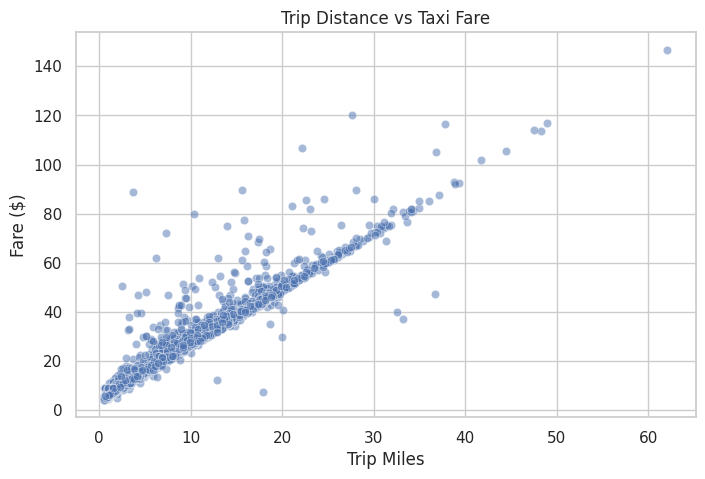

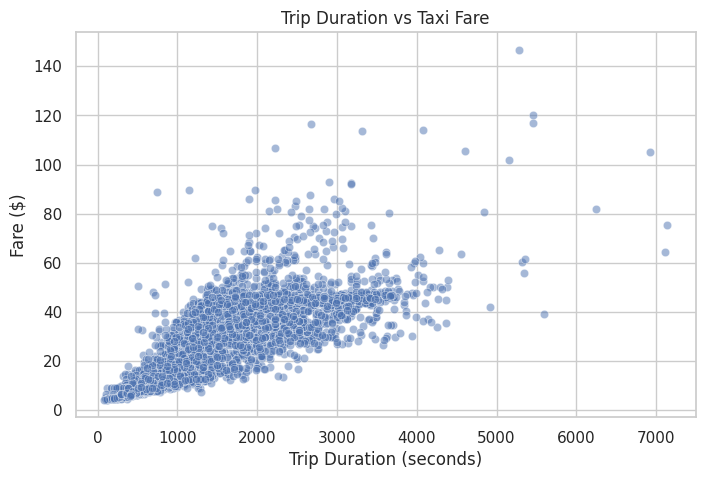

,TRIP_MILES,TRIP_SECONDS,FARE
TRIP_MILES,1.000000,0.800855,0.975344
TRIP_SECONDS,0.800855,1.000000,0.830292
FARE,0.975344,0.830292,1.000000


In [4]:
sample = model_df.sample(min(5000, len(model_df)), random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="TRIP_MILES", y="FARE", alpha=0.5)
plt.title("Trip Distance vs Taxi Fare")
plt.xlabel("Trip Miles")
plt.ylabel("Fare ($)")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="TRIP_SECONDS", y="FARE", alpha=0.5)
plt.title("Trip Duration vs Taxi Fare")
plt.xlabel("Trip Duration (seconds)")
plt.ylabel("Fare ($)")
plt.show()

display(model_df.corr(numeric_only=True))

In [5]:
X = model_df[["TRIP_MILES", "TRIP_SECONDS"]]
y = model_df["FARE"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 25355
Testing samples: 6339


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: 3.857050051628825
Coefficients: [2.01634244 0.00251816]


In [7]:
y_pred = model.predict(X_test)

results = pd.DataFrame({
    "Actual Fare": y_test.values,
    "Predicted Fare": y_pred
})

display(results.head(10))

,Actual Fare,Predicted Fare
0,14.84,15.814179
1,4.75,5.454671
2,33.50,33.371033
3,23.00,23.506082
4,9.68,9.730513
5,46.25,44.986090
6,9.75,10.514532
7,11.75,11.213712
8,58.71,45.016725
9,8.00,8.440453


In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: ${mae:.2f}")
print(f"RMSE: ${rmse:.2f}")
print(f"R² Score: {r2:.4f}")

MAE: $1.21
RMSE: $3.60
R² Score: 0.9561


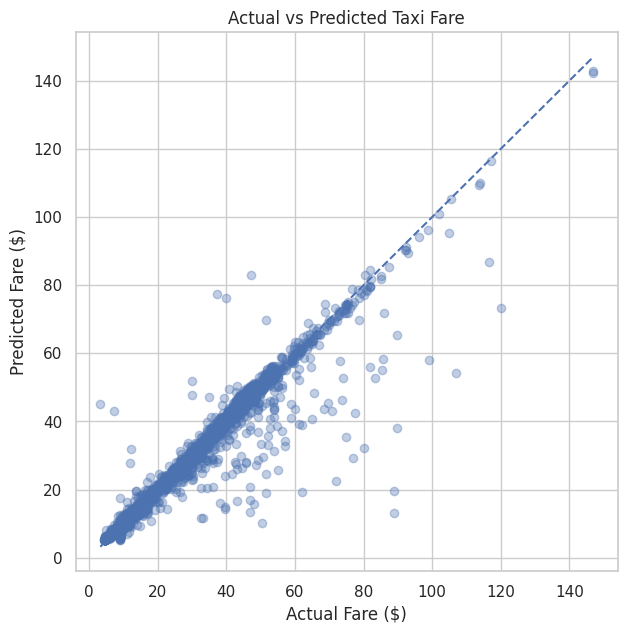

In [9]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.35)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")
plt.title("Actual vs Predicted Taxi Fare")
plt.xlabel("Actual Fare ($)")
plt.ylabel("Predicted Fare ($)")
plt.show()

In [11]:
new_trip = pd.DataFrame({
    "TRIP_MILES": [5.0],
    "TRIP_SECONDS": [1200]
})

predicted_fare = model.predict(new_trip)[0]
print(f"Predicted taxi fare: ${predicted_fare:.2f}")

Predicted taxi fare: $16.96
